## 데이터 시각화(1)(Data_Visualization)_(6월 16일) : 탐색적 데이터 분석을 위한 시각화

### *수업을 위한 data  활용을 위해 깃허브 연동하기

In [1]:
!git clone 'https://'github.com/KangKyungHwa/DSMH/''

fatal: destination path 'DSMH' already exists and is not an empty directory.


In [2]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

In [3]:
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.unicode_minus'] = False

In [4]:
import matplotlib.pyplot as plt

print("현재 Matplotlib 폰트 설정:", plt.rcParams['font.family']) #현재 설치된 폰트 확인


현재 Matplotlib 폰트 설정: ['NanumGothic']


### *seaborn라이브러리에서 제공하는 기본 데이터 활용을 위해 불러오기

In [5]:
import seaborn as sns
datasets = sns.get_dataset_names()
print([name for name in set(datasets)])

['brain_networks', 'iris', 'diamonds', 'exercise', 'attention', 'car_crashes', 'anagrams', 'healthexp', 'mpg', 'seaice', 'tips', 'flights', 'fmri', 'anscombe', 'dowjones', 'titanic', 'geyser', 'penguins', 'planets', 'taxis', 'glue', 'dots']


### *실습을 위한 flights 데이터 불러오기

In [6]:
import seaborn as sns
import pandas as pd
flights = pd.DataFrame(sns.load_dataset('flights'))
print(flights)

     year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]


In [7]:
print("\n ======Show flights's DataTypes====== \n")
print(flights.info())


 ======Show flights's DataTypes====== 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None


### 1.선 그래프: plot, lineplot

#### -연도별 평균 승객 수 구하고 그래프로 나타내보기

In [8]:
####  List or Array Vs Pandas의 DataFrame 시각화 차이 비교해 보기

f2 = flights.groupby(by='year')['passengers'].mean()

## 현재 데이터셋의 구조를 알고 싶을 때 사용
print(type(f2),'\n')

print(f2)

<class 'pandas.core.series.Series'> 

year
1949    126.666667
1950    139.666667
1951    170.166667
1952    197.000000
1953    225.000000
1954    238.916667
1955    284.000000
1956    328.250000
1957    368.416667
1958    381.000000
1959    428.333333
1960    476.166667
Name: passengers, dtype: float64


####-리스트와 배열 plot

=============================== LIst or Array ===================== 


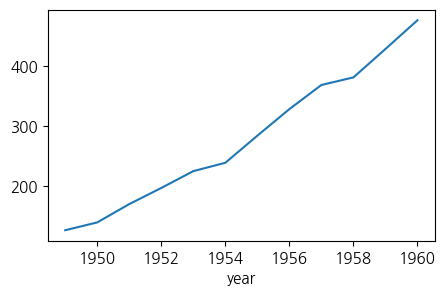

In [9]:
plt.rcParams['figure.figsize'] = (5, 3)
f2.plot()
print("=============================== LIst or Array ===================== ")
plt.show()

In [10]:
df_f2 = pd.DataFrame(flights.groupby(by='year')['passengers'].mean())
print(type(df_f2))
print(df_f2)

<class 'pandas.core.frame.DataFrame'>
      passengers
year            
1949  126.666667
1950  139.666667
1951  170.166667
1952  197.000000
1953  225.000000
1954  238.916667
1955  284.000000
1956  328.250000
1957  368.416667
1958  381.000000
1959  428.333333
1960  476.166667


####-데이터프레임 사용한 plot

============================ DataFrame 사용 ==================== 


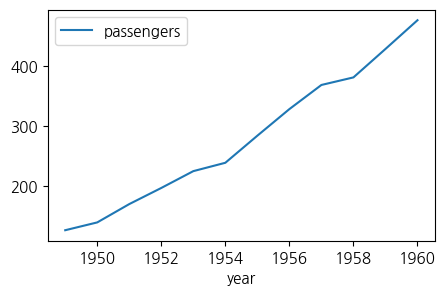

In [11]:
plt.rcParams['figure.figsize'] = (5, 3)
df_f2.plot()
print("============================ DataFrame 사용 ==================== ")
plt.show()


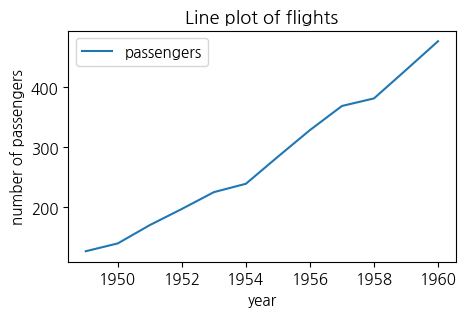

In [12]:
X = f2.index
Y = f2.values.ravel()

plt.plot(X, Y)
plt.xlabel('year')
plt.ylabel('number of passengers')
plt.legend(['passengers'])
plt.title('Line plot of flights')
plt.show()

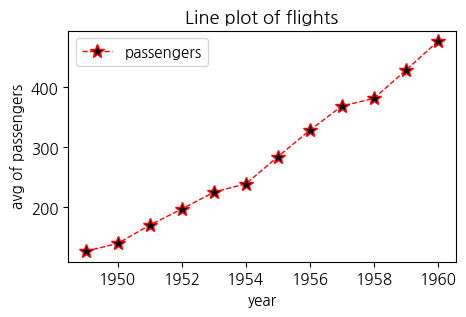

In [13]:
                                                #라인 너비   #라인 표시
plt.plot(X, Y, color='red', linestyle='dashed', linewidth=1,  marker='*',  markerfacecolor='black', markersize=10)
plt.xlabel('year')
plt.ylabel('avg of passengers')
plt.legend(['passengers'])
plt.title('Line plot of flights')
plt.show()

In [14]:
import numpy as np

#numpy 실행
#f3_ = flights.groupby(by='year')['passengers'].agg([np.mean, np.median, np.max])

#pandas 실행
f3 = flights.groupby(by='year')['passengers'].agg(['mean', 'median', 'max'])

#print(f3_)
print(f3)

            mean  median  max
year                         
1949  126.666667   125.0  148
1950  139.666667   137.5  170
1951  170.166667   169.0  199
1952  197.000000   192.0  242
1953  225.000000   232.0  272
1954  238.916667   231.5  302
1955  284.000000   272.0  364
1956  328.250000   315.0  413
1957  368.416667   351.5  467
1958  381.000000   360.5  505
1959  428.333333   406.5  559
1960  476.166667   461.0  622


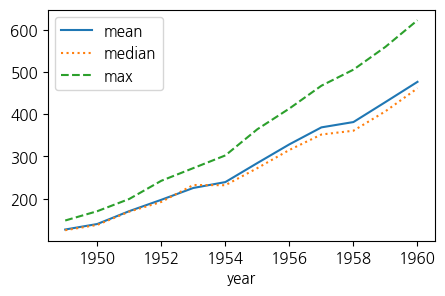

In [15]:
f3.plot(style=['-', ':', '--'])
plt.legend(['mean', 'median', 'max'])
plt.show()

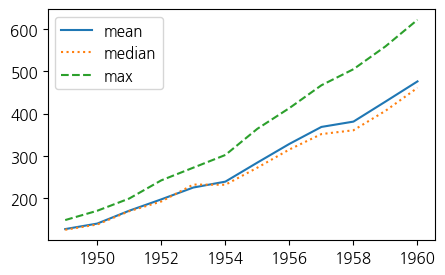

In [16]:
X = f3.index
Y1 = f3.iloc[:, 0].values  #mean
Y2 = f3.iloc[:, 1].values  #median
Y3 = f3.iloc[:, 2].values  #max

plt.plot(X, Y1, linestyle='solid', label='mean')
plt.plot(X, Y2, linestyle='dotted', label='median')
plt.plot(X, Y3, linestyle='dashed', label='max')
plt.legend()
plt.show()

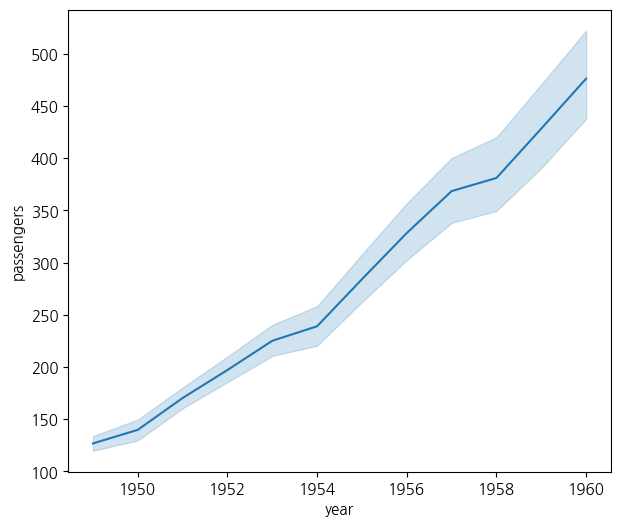

In [19]:
sns.lineplot(data=flights, x='year', y='passengers')
plt.show()

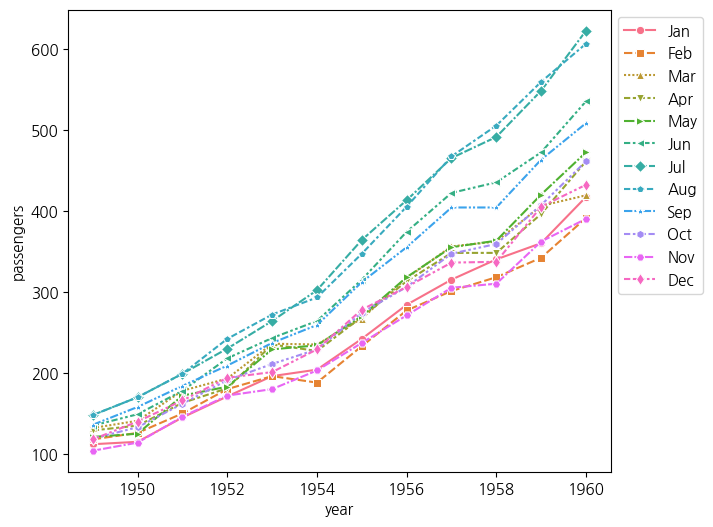

In [21]:
sns.lineplot(data=flights, x='year', y='passengers', hue='month', style='month',
            markers=['o', 's', '^', 'v', '>', '<', 'D', 'p', '*', 'h', 'H', 'd'] )
plt.rcParams['figure.figsize'] = (7, 6)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

### 2.누적 연속 그래프: stackplot

In [24]:
import seaborn as sns
healthexp = sns.load_dataset('healthexp').query("Year >= 1992")
#healthexp = healthexp.reset_index(drop=False)
healthexp = healthexp.reset_index(drop=True)
#1992년 이후 자료이기 때문애 기존 인덱스 버리고 0부터 재시작
print(healthexp)

     Year        Country  Spending_USD  Life_Expectancy
0    1992         Canada      1897.456             77.8
1    1992        Germany      2019.308             76.1
2    1992         France      1651.139             77.5
3    1992  Great Britain       930.701             76.3
4    1992          Japan      1253.415             79.2
..    ...            ...           ...              ...
169  2020        Germany      6938.983             81.1
170  2020         France      5468.418             82.3
171  2020  Great Britain      5018.700             80.4
172  2020          Japan      4665.641             84.7
173  2020            USA     11859.179             77.0

[174 rows x 4 columns]


In [25]:
Country = healthexp['Country'].unique()
Spendings = []
for country in Country:
    spending = healthexp[healthexp['Country']==country]['Spending_USD'].values
    Spendings.append(spending)
    print(country, len(spending))

Canada 29
Germany 29
France 29
Great Britain 29
Japan 29
USA 29


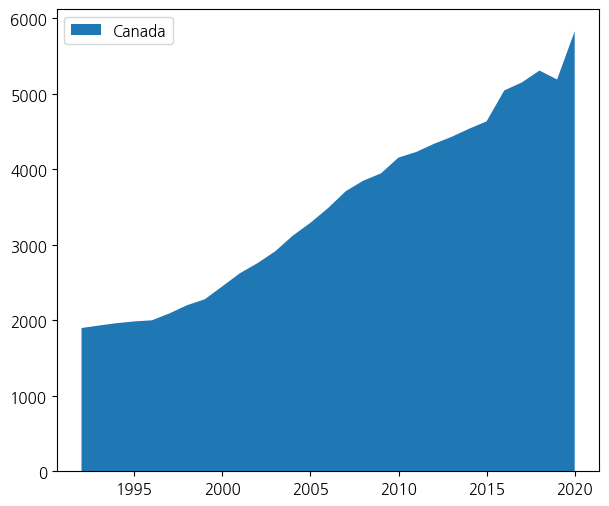

In [26]:
i = 0
Year = healthexp['Year'].unique()
plt.stackplot(Year, Spendings[i], labels=[Country[i]])
plt.legend()
plt.show()

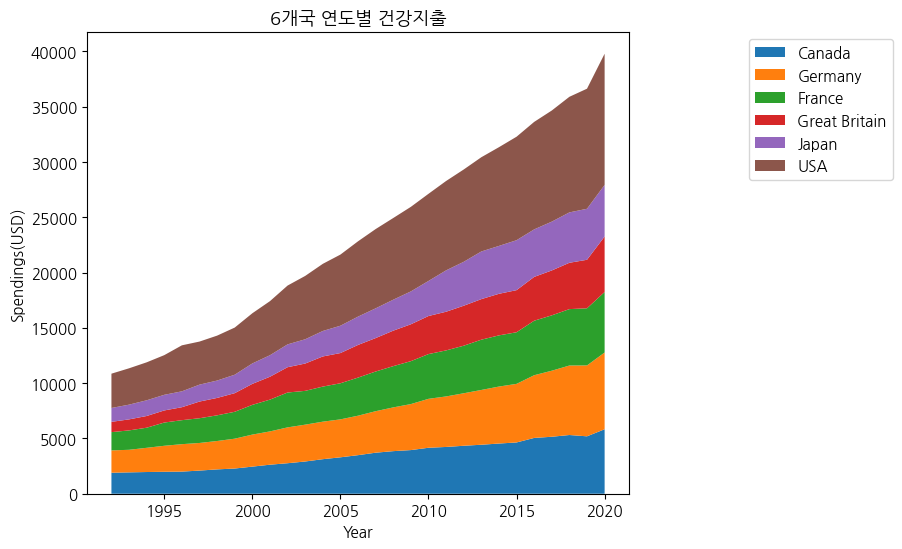

In [29]:
plt.stackplot(Year, Spendings[0], Spendings[1], Spendings[2], Spendings[3], Spendings[4], Spendings[5], labels=Country)
plt.legend(bbox_to_anchor=(1.5, 1))
plt.title('6개국 연도별 건강지출')
plt.xlabel('Year')
plt.ylabel('Spendings(USD)')
plt.show()

### 3.막대 그래프: plot, countplot, barplot

In [35]:
import seaborn as sns
mpg = sns.load_dataset('mpg')
print(mpg)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu  
1            70     usa      

In [33]:
m2 = mpg['origin'].value_counts()
print(m2)

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


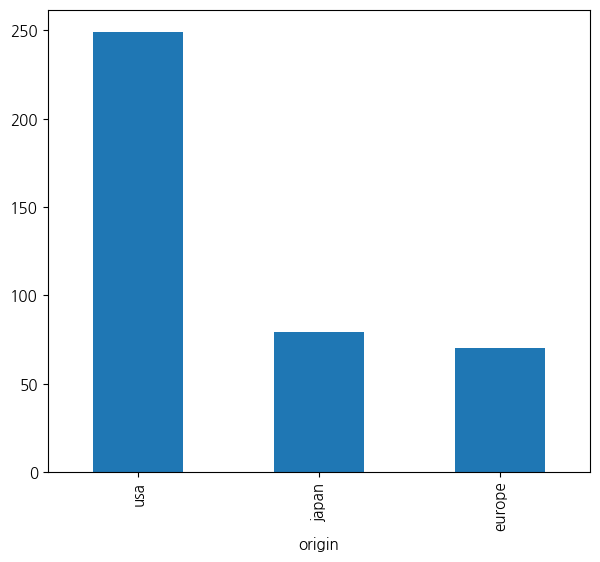

In [34]:
m2.plot(kind='bar')
plt.show()

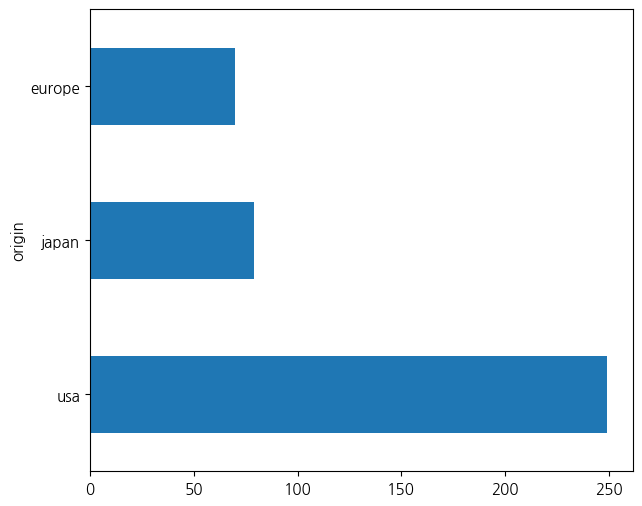

In [36]:
m2.plot(kind='barh')
plt.show()

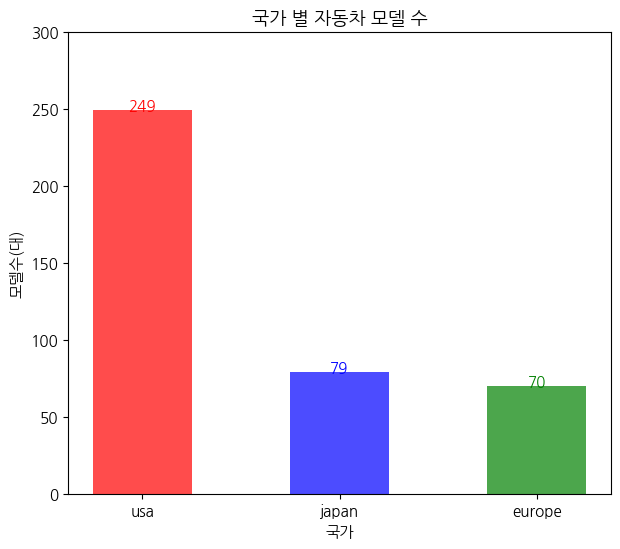

In [42]:
origins = m2.index
counts = m2.values
colors = ['red', 'blue', 'green']
plt.bar(origins, counts, color=colors,
        width=0.5, alpha=0.7)
plt.ylim(0, 300)
plt.title('국가 별 자동차 모델 수')
plt.xlabel('국가')
plt.ylabel('모델수(대)')

for x, y, text, c in zip(range(len(origins)), counts, counts, colors):
    plt.text(x, y, text, horizontalalignment='center', color=c)
plt.show()

In [43]:
from pandas import pivot_table
m3 = pivot_table(index='origin', columns='cylinders',
                 values='name', aggfunc='count', data=mpg)
print(m3)

cylinders    3     4    5     6      8
origin                                
europe     NaN  63.0  3.0   4.0    NaN
japan      4.0  69.0  NaN   6.0    NaN
usa        NaN  72.0  NaN  74.0  103.0


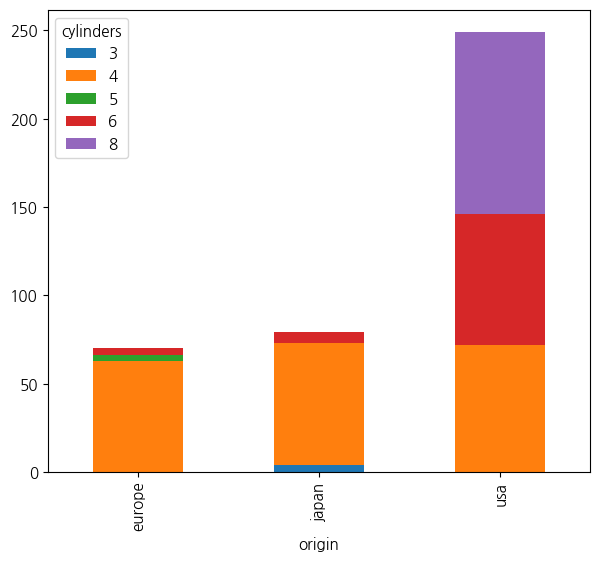

In [46]:
m3.plot(kind='bar', stacked=True)
plt.show()

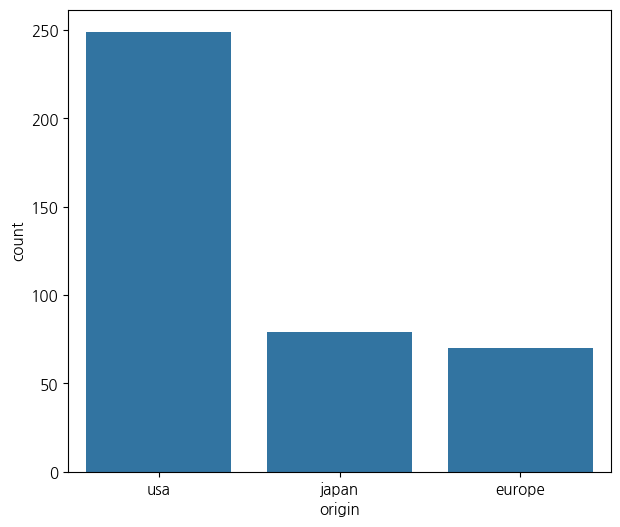

In [45]:
sns.countplot(x='origin', data=mpg)
plt.show()

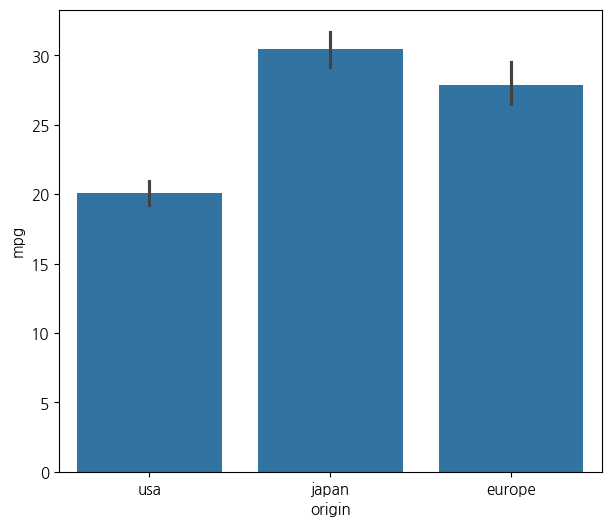

In [47]:
sns.barplot(x='origin', y='mpg', data=mpg)
plt.show()

### 4.히스토그램과 KDE 곡선: hist, histplot
#### -Kernel Density Estimation (커널 밀도 추정) : 데이터의 분포를 부드러운 곡선으로 나타내어주는 방법

In [48]:
import seaborn as sns
mpg = sns.load_dataset('mpg')
print(mpg)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu  
1            70     usa      

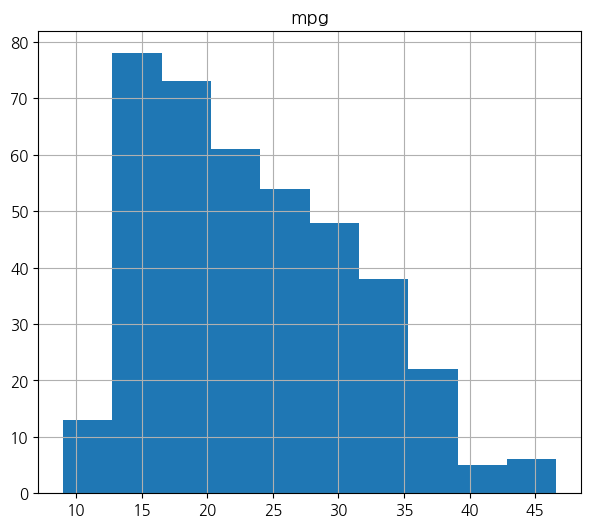

In [49]:
mpg[['mpg']].hist()
plt.show()

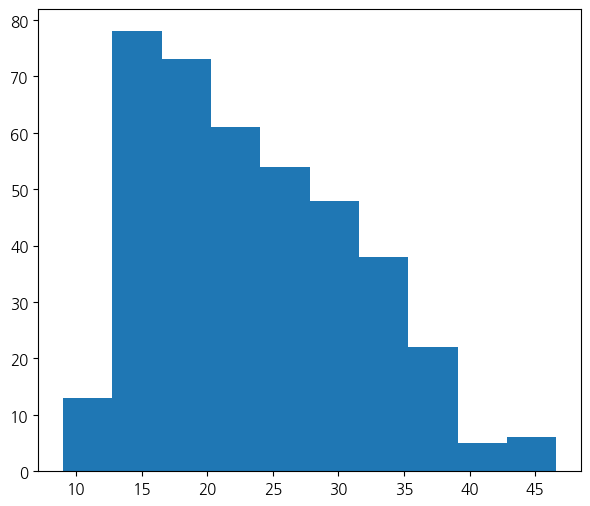

In [50]:
mpgs = mpg['mpg'].values

plt.hist(mpgs)
plt.show()

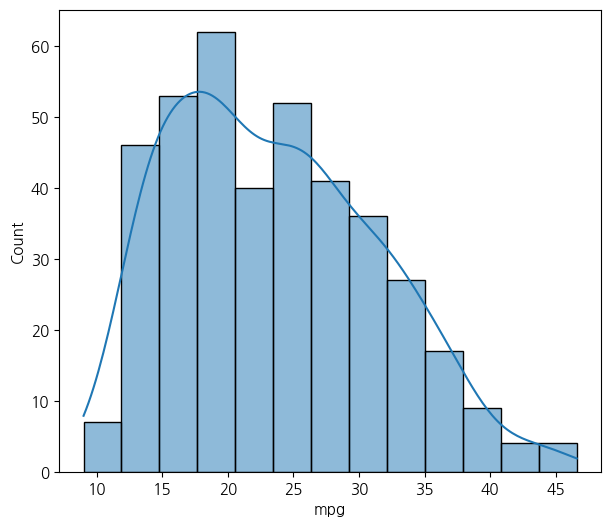

In [52]:
sns.histplot(x='mpg', data=mpg, kde=True)
plt.show()

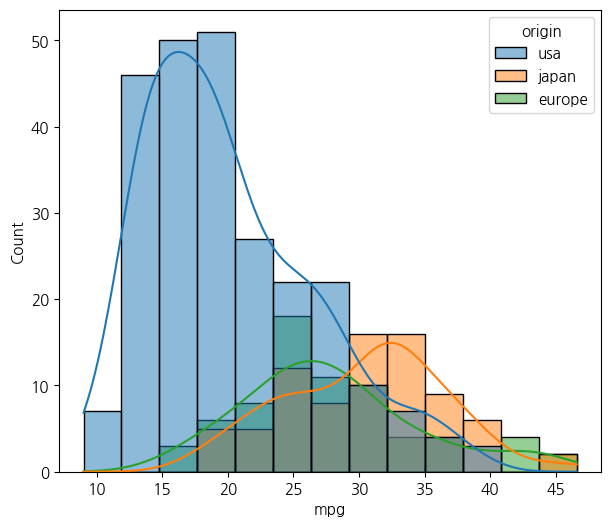

In [51]:
sns.histplot(x='mpg', data=mpg,
             hue='origin',
             kde=True)
plt.show()